### Configuration

In [9]:
import numpy as np
import os
import pickle
import pandas as pd
import json
from tqdm import tqdm
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics
from methyldl.deconvolution.uxm import load_atlas, uxm_deconvolution, rearange_uxm_deconvolution_results
from edautils import plot_deconvolution_results
uxm_features_path = "/home/luna.kuleuven.be/u0169940/Repos/methyldl/Experiments/pseudobulk/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_pooled_jakkard_no_data_leak_d041/pseudobulk/ios_deconvolution/ios_deconvolution"

In [10]:
ios_files = os.listdir(uxm_features_path)

In [11]:
with open("../App/labels_dict.json", "rb") as f:
    labels_dict = json.load(f) 
labels_dict = {int(key):value for (key,value) in labels_dict.items()}
labels_dict_reversed = {y: x for (x, y) in labels_dict.items()}

In [12]:
atlas_location = "../../UXM_deconv/supplemental/Atlas.U25.l4.hg38.full.tsv"
atlas, ref_cells = load_atlas(atlas_location, ignore=["Megakaryocytes"])
atlas = atlas.sort_values(by=["chr", "start", "end"], ascending=True).reset_index(
    drop=True
)

### Deconvolution

In [13]:
uxm_results_test = []
uxm_results_valid = []
uxm_results_train = []
target_proportions = []
for file in tqdm(ios_files):
    with open(os.path.join(uxm_features_path, file), "rb") as f:
        res = pickle.load(f)
        for j in range(len(res)):
            for split_id in [0,1,2]:
                props = res[j][0]
                sf = res[j][2][split_id][0]
                counts = res[j][2][split_id][1]
                uxm_proportions = uxm_deconvolution(
                    atlas, ref_cells, sf, counts, sample_names=['pseudo_bulk_sample']
                )[0]
                uxm_deconv_alligned = rearange_uxm_deconvolution_results(
                    labels_dict_reversed, uxm_proportions, ref_cells
                )
                if split_id==2:
                    uxm_results_test.append(uxm_deconv_alligned)
                elif split_id==1:
                    uxm_results_valid.append(uxm_deconv_alligned)
                else:
                    uxm_results_train.append(uxm_deconv_alligned)
            target_proportions.append(props)

100%|██████████| 100/100 [18:04<00:00, 10.85s/it]


In [ ]:
target_proportions = np.array(target_proportions)
uxm_results_test = np.array(uxm_results_test)
uxm_results_valid = np.array(uxm_results_valid)
uxm_results_train = np.array(uxm_results_train)

In [ ]:
metrics = compute_deconvolution_metrics(uxm_results_test, target_proportions)

In [46]:
metrics

{'mae': 0.00556341647797364,
 'mse': 0.00029389506195860797,
 'kl': 0.1456824175048089,
 'max_error': 0.5138003510308036,
 'cosine_sim': 0.9850402915172394,
 'loa_lower': -0.03360100533487703,
 'loa_upper': 0.03360100533487703,
 'loa_width': 0.06720201066975406,
 'worst_class_idx': 11,
 'worst_class_name': 11,
 'worst_class_loa_lower': -0.06871436413236422,
 'worst_class_loa_upper': 0.09568783893939918,
 'worst_class_loa_width': 0.1644022030717634,
 'per_class_loa': {'bias': array([-5.57171434e-03, -1.22598507e-03, -2.84051379e-03, -5.60452641e-04,
          1.81379967e-03,  1.00706120e-02,  5.62872911e-04,  1.15965599e-02,
          1.61606610e-03, -1.94241041e-03, -1.62439371e-03,  1.34867374e-02,
         -2.55973485e-03, -1.81018132e-03,  1.98326374e-03, -1.42058249e-04,
          5.76037155e-04, -1.16102614e-03, -5.87143649e-04, -4.18090629e-04,
         -1.34098649e-03, -4.76704180e-03, -2.54606614e-03, -7.22545623e-05,
         -1.07739222e-03,  4.32622357e-04, -2.31801830e-03, 

(<Figure size 2000x1000 with 2 Axes>,
 {'celltype_metrics': {'overall_r2': 0.964509234709998,
   'per_celltype_r2': {'Adipocytes': 0.9398842793678348,
    'Bladder-Ep': 0.9778725280500754,
    'Blood-B': 0.9549224619529223,
    'Blood-Granul': 0.9932516621938583,
    'Blood-Mono+Macro': 0.98737888971058,
    'Blood-NK': 0.9264884410192042,
    'Blood-T': 0.9839732978543244,
    'Bone-Osteob': 0.9073371438484286,
    'Breast-Basal-Ep': 0.9929645557992688,
    'Breast-Luminal-Ep': 0.9846571997813853,
    'Colon-Ep': 0.9911292056618393,
    'Colon-Fibro': 0.7670155122567163,
    'Dermal-Fibro': 0.8361801030966326,
    'Endothel': 0.9382926329322366,
    'Epid-Kerat': 0.9715090724723642,
    'Eryth-prog': 0.9718408637608529,
    'Fallopian-Ep': 0.9676710778669739,
    'Gallbladder': 0.9855704020864019,
    'Gastric-Ep': 0.9911490350473007,
    'Head-Neck-Ep': 0.9916102409578869,
    'Heart-Cardio': 0.987676840290978,
    'Heart-Fibro': 0.9490141774710655,
    'Kidney-Ep': 0.978951557548360

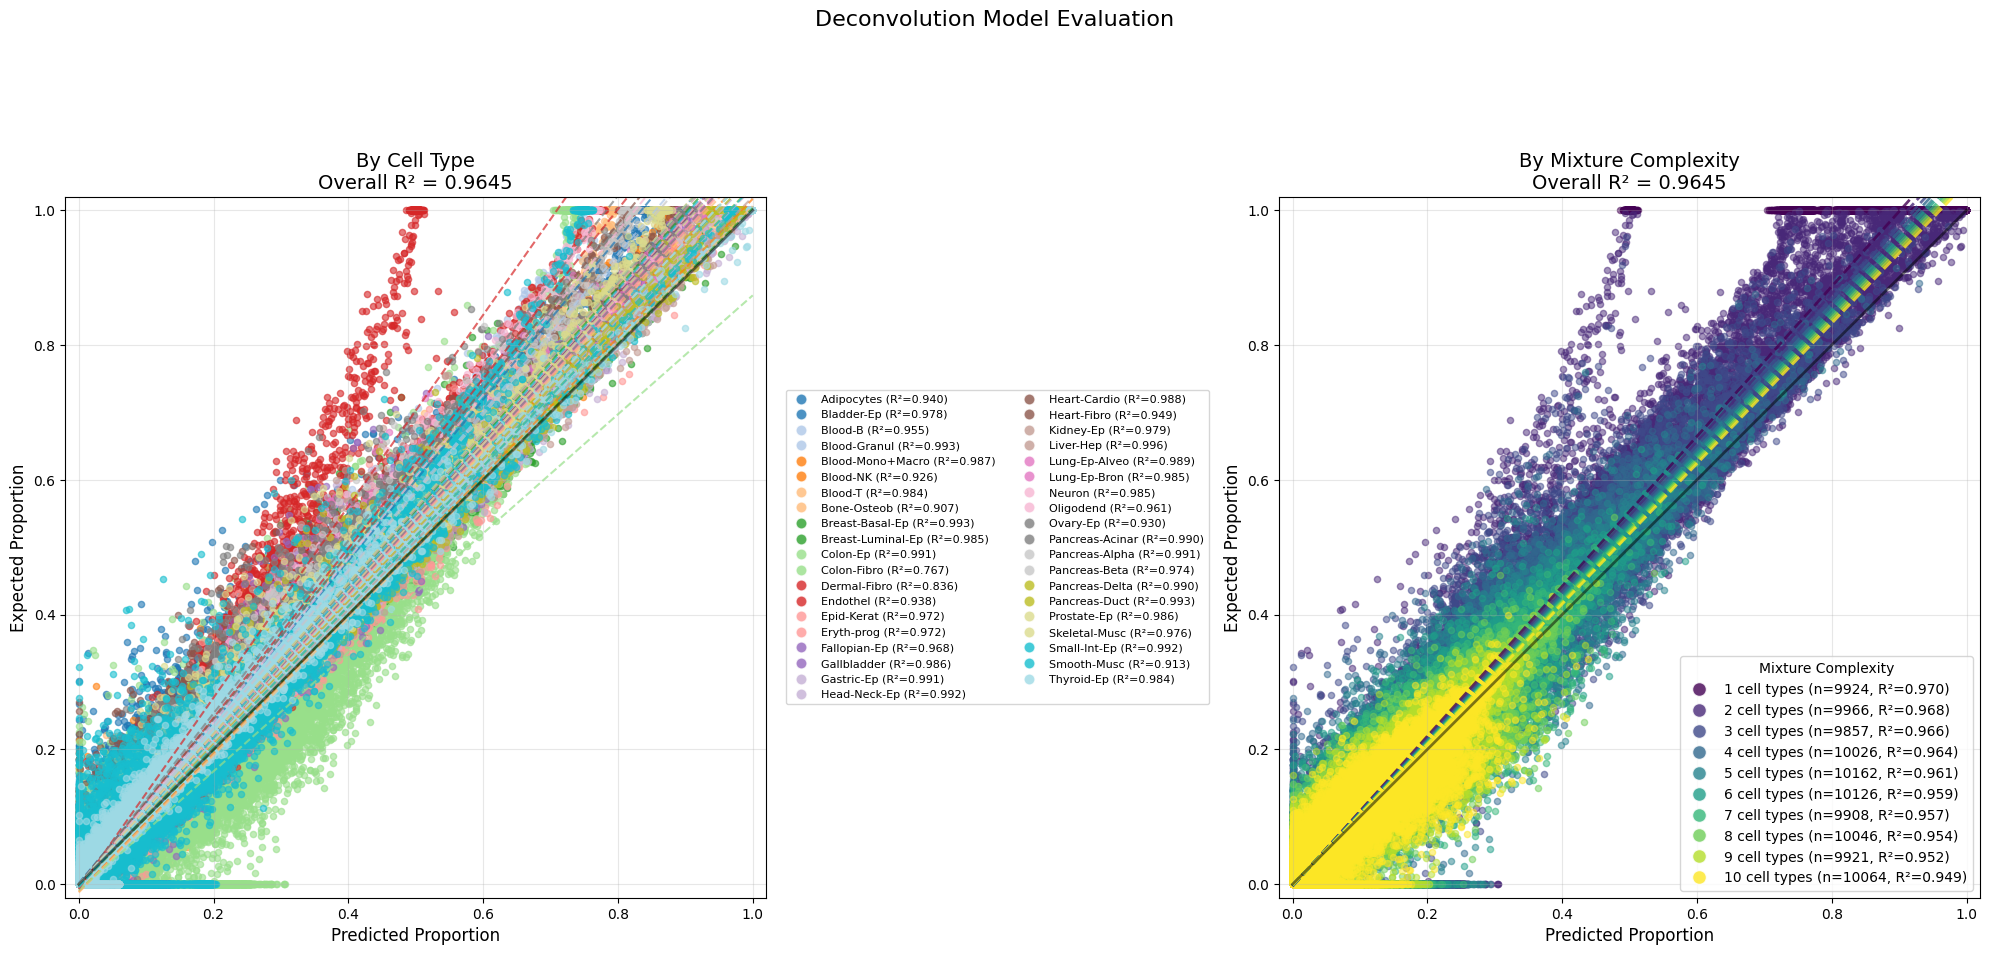

In [ ]:
plot_deconvolution_results(target_proportions, uxm_results_test, labels_dict=labels_dict)

### Linear Calibration

In [51]:
from methyldl.deconvolution.linear_calibrator import LinearCalibrator

In [53]:
calibrator = LinearCalibrator()
calibrator.fit(uxm_results_valid, target_proportions)
calibrated_test_pred, _ = calibrator.predict(uxm_results_test)

metrics = compute_deconvolution_metrics(calibrated_test_pred, target_proportions)
calibrated_test_pred = np.round(calibrated_test_pred, 4)

In [54]:
metrics

{'mae': 0.005032566876163163,
 'mse': 0.0002547000287063544,
 'kl': 0.13353367747637673,
 'max_error': 0.4117063482919746,
 'cosine_sim': 0.9857781211321259,
 'loa_lower': -0.03128027942913002,
 'loa_upper': 0.03128027942913002,
 'loa_width': 0.06256055885826003,
 'worst_class_idx': 11,
 'worst_class_name': 11,
 'worst_class_loa_lower': -0.06362676670045496,
 'worst_class_loa_upper': 0.08555198720678671,
 'worst_class_loa_width': 0.14917875390724167,
 'per_class_loa': {'bias': array([-0.00408869,  0.00093779, -0.00182166, -0.00120106, -0.00050023,
          0.01026956, -0.00060095,  0.00817917,  0.00101052, -0.00298206,
         -0.00172025,  0.01096261,  0.00510424, -0.00364454,  0.00204124,
          0.00280311, -0.00078844, -0.00238875, -0.00101279, -0.0015539 ,
         -0.00108491, -0.00529731, -0.0019414 , -0.00058721, -0.00095581,
          0.00185525, -0.00251906, -0.00168382, -0.00243509, -0.00092651,
         -0.00110695, -0.00251454,  0.00265426, -0.00125253, -0.00042079,
  

(<Figure size 2000x1000 with 2 Axes>,
 {'celltype_metrics': {'overall_r2': 0.9692422981057718,
   'per_celltype_r2': {'Adipocytes': 0.9576685088420991,
    'Bladder-Ep': 0.9843671179097694,
    'Blood-B': 0.9629547454161692,
    'Blood-Granul': 0.9918691942511038,
    'Blood-Mono+Macro': 0.984621114648329,
    'Blood-NK': 0.9286741577212219,
    'Blood-T': 0.9857131266195417,
    'Bone-Osteob': 0.9321061061083875,
    'Breast-Basal-Ep': 0.9925122175202653,
    'Breast-Luminal-Ep': 0.9803099417524136,
    'Colon-Ep': 0.9902280610115528,
    'Colon-Fibro': 0.8117182242425334,
    'Dermal-Fibro': 0.8863456205071363,
    'Endothel': 0.9351889420945001,
    'Epid-Kerat': 0.9766670707080768,
    'Eryth-prog': 0.9739106805328084,
    'Fallopian-Ep': 0.9647268742307099,
    'Gallbladder': 0.98152995805051,
    'Gastric-Ep': 0.9907699746989126,
    'Head-Neck-Ep': 0.9903514250830519,
    'Heart-Cardio': 0.9890747612674969,
    'Heart-Fibro': 0.941561544674276,
    'Kidney-Ep': 0.984142837821208

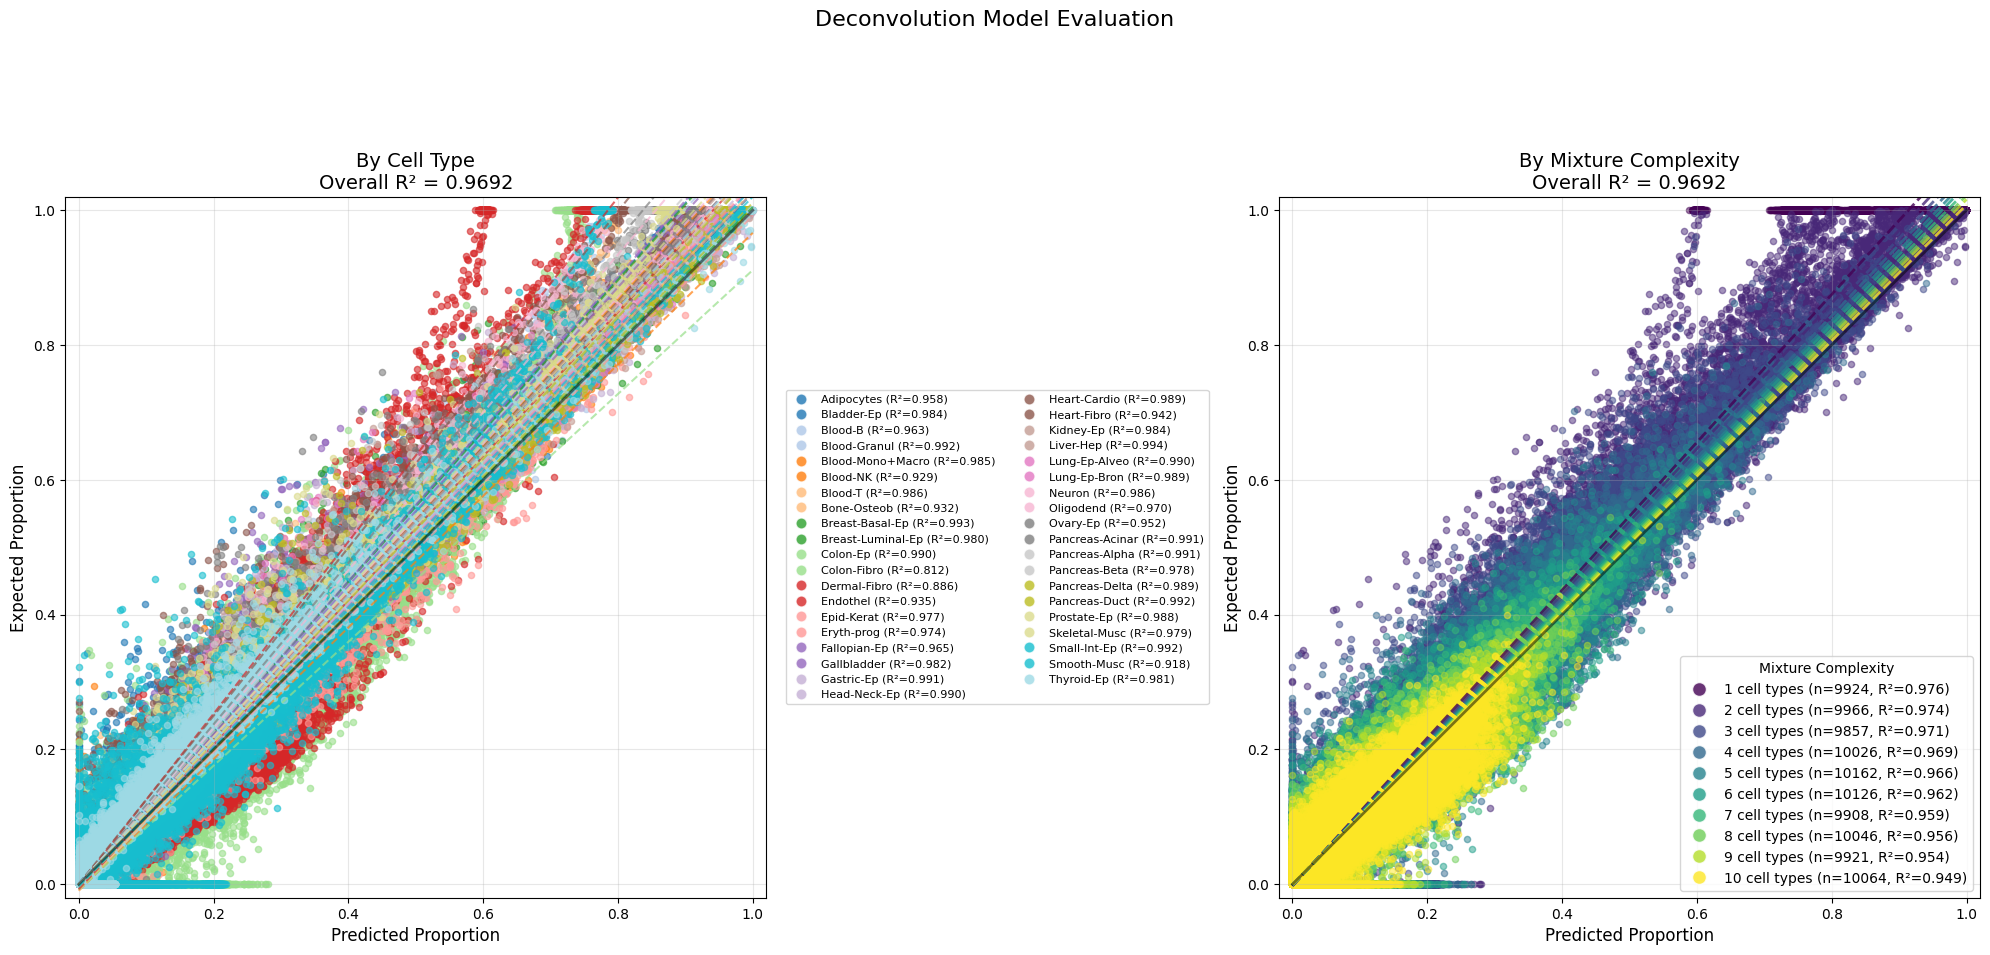

In [55]:
plot_deconvolution_results(target_proportions, calibrated_test_pred, labels_dict=labels_dict)

### Save results

#### Features

In [57]:
from collections import defaultdict

In [61]:
features = defaultdict(lambda: defaultdict(list))

splits_names = ["train", "valid", "test"]
for file in tqdm(ios_files):
    with open(os.path.join(uxm_features_path, file), "rb") as f:
        res = pickle.load(f)
        for j in range(len(res)):
            for split_id in [0,1,2]:
                # test split only
                sf = res[j][2][split_id][0]
                counts = res[j][2][split_id][1]
                features[splits_names[split_id]]["sf"].append(sf)
                features[splits_names[split_id]]["counts"].append(counts)

100%|██████████| 100/100 [06:53<00:00,  4.14s/it]


In [ ]:
features["target_proportions"] = target_proportions

In [17]:
save_path = "/home/luna.kuleuven.be/u0169940/Repos/methyldl/Experiments/pseudobulk/uxm_results_pseudobulk"

In [67]:
with open(os.path.join(save_path,"uxm_input_features.pkl"), "wb") as f:
    pickle.dump(dict(features), f)

##### Predictions

In [ ]:
np.savez(os.path.join(save_path,"uxm_results_test"), uxm_results_test)
np.savez(os.path.join(save_path,"uxm_results_valid"), uxm_results_valid)
np.savez(os.path.join(save_path,"uxm_results_train"), uxm_results_train)

In [21]:
np.savez(os.path.join(save_path,"target_proportions"), target_proportions)

##### Callibrator

In [69]:
calibrator.save_calibration_parameters(f"{save_path}/uxm_linear_calibrator.npz")